# μP Feature Learning 分析

本 notebook 可独立运行，复用官方 demo 的模型定义和数据处理。

### 实验列表
- **A**: ||ΔW||/||W₀|| vs Width — 验证 μP 保持 Θ(1) feature learning
- **B**: Hidden Feature cosine similarity — NTK 不变 vs μP 变化
- **C**: 权重分布 & 奇异值谱演化 — μP 出现 outlier spike
- **D**: 完整训练曲线 — train/test loss+acc 对比

In [1]:
import time
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib

from mup import MuSGD, get_shapes, set_base_shapes, make_base_shapes, MuReadout

matplotlib.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name()}')

Device: cuda
  GPU: NVIDIA GeForce RTX 4090


## 数据 & 模型 (与官方 demo 一致)

In [2]:
batch_size = 64
epochs = 20
log_interval = 300
nonlin = torch.relu
criterion = F.cross_entropy
data_dir = '/tmp'
base_shapes_path = '/tmp/demo_width256.bsh'

torch.manual_seed(1)
kwargs = {'num_workers': 1, 'pin_memory': True} if device.type == 'cuda' else {}

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, **kwargs)

testset = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, **kwargs)

print(f'Train: {len(trainset)}, Test: {len(testset)}')

Train: 50000, Test: 10000


In [4]:
def train(model, device, train_loader, optimizer, epoch,
          scheduler=None, criterion=F.cross_entropy):
    model.train()
    train_loss = 0.
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device).view(data.size(0), -1), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        train_loss += loss.item() * data.size(0)
    train_loss /= len(train_loader.dataset)
    return train_loss


@torch.no_grad()
def evaluate(model, device, loader, criterion=F.cross_entropy):
    model.eval()
    tl, tc, tn = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device).view(x.size(0), -1), y.to(device)
        out = model(x)
        tl += criterion(out, y).item() * x.size(0)
        tc += (out.argmax(1) == y).sum().item()
        tn += x.size(0)
    return tl / tn, tc / tn

In [5]:
class MLP(nn.Module):
    """SP model"""
    def __init__(self, width=128, num_classes=10, nonlin=F.relu, output_mult=1.0, input_mult=1.0):
        super(MLP, self).__init__()
        self.nonlin = nonlin
        self.input_mult = input_mult
        self.output_mult = output_mult
        self.fc_1 = nn.Linear(3072, width, bias=False)
        self.fc_2 = nn.Linear(width, width, bias=False)
        self.fc_3 = nn.Linear(width, num_classes, bias=False)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.fc_1.weight, a=1, mode='fan_in')
        self.fc_1.weight.data /= self.input_mult**0.5
        nn.init.kaiming_normal_(self.fc_2.weight, a=1, mode='fan_in')
        nn.init.zeros_(self.fc_3.weight)

    def forward(self, x):
        out = self.nonlin(self.fc_1(x) * self.input_mult**0.5)
        out = self.nonlin(self.fc_2(out))
        return self.fc_3(out) * self.output_mult


class muMLP(nn.Module):
    """muP model"""
    def __init__(self, width=128, num_classes=10, nonlin=F.relu, output_mult=1.0, input_mult=1.0):
        super(muMLP, self).__init__()
        self.nonlin = nonlin
        self.input_mult = input_mult
        self.output_mult = output_mult
        self.fc_1 = nn.Linear(3072, width, bias=False)
        self.fc_2 = nn.Linear(width, width, bias=False)
        self.fc_3 = MuReadout(width, num_classes, bias=False, output_mult=self.output_mult)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.fc_1.weight, a=1, mode='fan_in')
        self.fc_1.weight.data /= self.input_mult**0.5
        nn.init.kaiming_normal_(self.fc_2.weight, a=1, mode='fan_in')
        nn.init.zeros_(self.fc_3.weight)

    def forward(self, x):
        out = self.nonlin(self.fc_1(x) * self.input_mult**0.5)
        out = self.nonlin(self.fc_2(out))
        return self.fc_3(out)

In [6]:
base_shapes = get_shapes(MLP(width=256, nonlin=nonlin))
delta_shapes = get_shapes(MLP(width=256 + 1, nonlin=nonlin))
make_base_shapes(base_shapes, delta_shapes, savefile=base_shapes_path)

output_mult = 32
input_mult = 0.00390625  # 1/256

print(f'base_width=256, output_mult={output_mult}, input_mult={input_mult}')
print(f'Saved base shapes to {base_shapes_path}')

base_width=256, output_mult=32, input_mult=0.00390625
Saved base shapes to /tmp/demo_width256.bsh


---
## 实验 A: ||ΔW||/||W₀|| vs Width

- **NTK (lazy)**: 所有参数 lr /= width → 权重几乎不动, ||ΔW||/||W₀|| → 0
- **μP**: MuSGD 精确 scaling → 隐藏层有 **Θ(1)** 相对更新
- **SP**: 普通 SGD → 行为不可控

In [7]:
def measure_weight_change(mode, widths, lr=0.1, ep=10, seed=1):
    records = []
    print(f'\n=== {mode.upper()} lr={lr} epochs={ep} ===')
    print(f'{"width":>6s} | {"tr_loss":>8s} {"tr_acc":>7s} | '
          f'{"te_loss":>8s} {"te_acc":>7s} | '
          f'{"fc_1":>12s} | {"fc_2":>12s} | {"fc_3":>12s}')
    print('-' * 90)

    for w in widths:
        torch.manual_seed(seed)
        if mode == 'mup':
            net = muMLP(width=w, nonlin=nonlin,
                        output_mult=output_mult, input_mult=input_mult).to(device)
            set_base_shapes(net, base_shapes_path)
            opt = MuSGD(net.parameters(), lr=lr)
        elif mode == 'ntk':
            net = muMLP(width=w, nonlin=nonlin,
                        output_mult=output_mult, input_mult=input_mult).to(device)
            set_base_shapes(net, base_shapes_path)
            opt = SGD(net.parameters(), lr=lr / w)
        else:  # sp
            net = MLP(width=w, nonlin=nonlin,
                      output_mult=output_mult, input_mult=input_mult).to(device)
            opt = SGD(net.parameters(), lr=lr)

        w0 = {n: p.data.clone() for n, p in net.named_parameters()}

        for e in range(1, ep + 1):
            train(net, device, train_loader, opt, e, criterion=criterion)

        tr_l, tr_a = evaluate(net, device, train_loader, criterion)
        te_l, te_a = evaluate(net, device, test_loader, criterion)

        rels = {}
        for n, p in net.named_parameters():
            dn = (p.data - w0[n]).norm().item()
            wn = w0[n].norm().item()
            rels[n] = dn / (wn + 1e-10)
            records.append({'width': w, 'layer': n, 'mode': mode, 'rel': rels[n]})

        print(f'{w:>6d} | {tr_l:>8.4f} {tr_a:>7.3f} | '
              f'{te_l:>8.4f} {te_a:>7.3f} | '
              f'{rels["fc_1.weight"]:>12.6f} | '
              f'{rels["fc_2.weight"]:>12.6f} | '
              f'{rels["fc_3.weight"]:>12.6f}')

    return records

In [8]:
widths_fl = [128, 256, 512, 1024, 2048, 4096, 8192]

r_mup = measure_weight_change('mup', widths_fl, lr=0.1)
r_ntk = measure_weight_change('ntk', widths_fl, lr=1.0)
r_sp  = measure_weight_change('sp',  widths_fl, lr=0.1)


=== MUP lr=0.1 epochs=10 ===
 width |  tr_loss  tr_acc |  te_loss  te_acc |         fc_1 |         fc_2 |         fc_3
------------------------------------------------------------------------------------------


/tmp/ipykernel_659/2795930788.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  train_loss += loss.item() * data.size(0)


   128 |   1.8473   0.370 |   2.0390   0.334 |     0.042181 |     1.105618 | 36429550647.735596
   256 |   1.3274   0.539 |   1.8633   0.427 |     0.047293 |     1.065292 | 63029270172.119141
   512 |   0.9351   0.672 |   1.9413   0.457 |     0.052083 |     1.010806 | 123622636795.043945
  1024 |   0.7052   0.793 |   2.2744   0.455 |     0.056779 |     0.872618 | 217423820495.605469
  2048 |   0.2269   0.929 |   2.2783   0.516 |     0.057020 |     0.710871 | 349188117980.957031
  4096 |   0.1509   0.953 |   2.3218   0.523 |     0.056446 |     0.522530 | 554892387390.136719
  8192 |   0.1287   0.960 |   2.2925   0.531 |     0.055299 |     0.378850 | 881180038452.148438

=== NTK lr=1.0 epochs=10 ===
 width |  tr_loss  tr_acc |  te_loss  te_acc |         fc_1 |         fc_2 |         fc_3
------------------------------------------------------------------------------------------
   128 |   1.6068   0.417 |   1.7703   0.373 |     0.011058 |     0.356837 | 10269490480.422974
   256 |   1.463

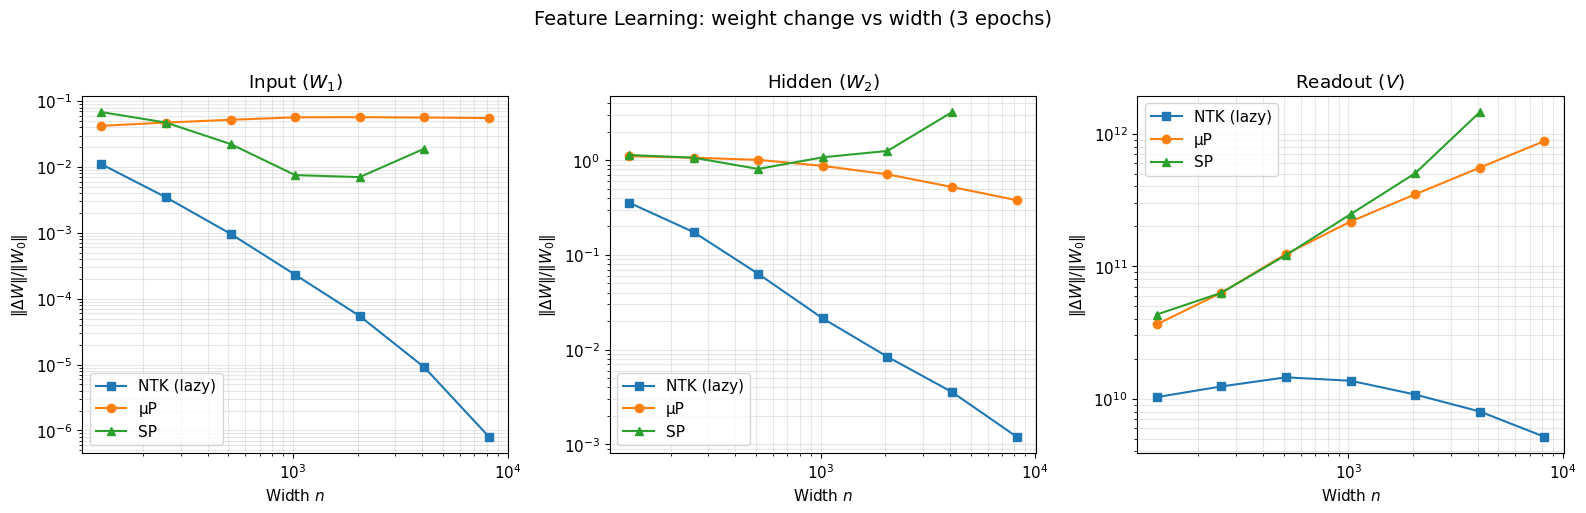


NTK: ||dW||/||W0|| ~ 1/n -> 0  (lazy)
muP: ||dW||/||W0|| ~ Theta(1)   (feature learning)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
layers = ['fc_1.weight', 'fc_2.weight', 'fc_3.weight']
titles = ['Input ($W_1$)', 'Hidden ($W_2$)', 'Readout ($V$)']

for idx, (l, t) in enumerate(zip(layers, titles)):
    ax = axes[idx]
    for rec, lb, mk, c in [
        (r_ntk, 'NTK (lazy)', 's', 'C0'),
        (r_mup, 'μP', 'o', 'C1'),
        (r_sp, 'SP', '^', 'C2'),
    ]:
        d = sorted([(r['width'], r['rel']) for r in rec if r['layer'] == l])
        if d:
            ws, vs = zip(*d)
            ax.loglog(ws, vs, f'{mk}-', label=lb, ms=6, color=c)
    ax.set_xlabel('Width $n$')
    ax.set_ylabel(r'$\|\Delta W\| / \|W_0\|$')
    ax.set_title(t)
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

fig.suptitle('Feature Learning: weight change vs width (3 epochs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nNTK: ||dW||/||W0|| ~ 1/n -> 0  (lazy)')
print('muP: ||dW||/||W0|| ~ Theta(1)   (feature learning)')

---
## 实验 B: Hidden Feature 变化

- cos(h₀, h_T) ≈ 1 → 特征没变（lazy）
- cos 显著偏离 1 → 学到了新特征

In [10]:
def get_hidden(model, loader, n_batch=5):
    model.eval()
    hs = []
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_batch:
                break
            x = x.to(device).view(x.size(0), -1)
            h = model.nonlin(model.fc_1(x) * model.input_mult**0.5)
            hs.append(h.cpu())
    return torch.cat(hs, 0)


def feature_experiment(mode, width=4096, lr=0.1, ep=5, seed=1):
    print(f'\n=== {mode.upper()} w={width} ===')
    torch.manual_seed(seed)

    if mode == 'mup':
        net = muMLP(width=width, nonlin=nonlin,
                    output_mult=output_mult, input_mult=input_mult).to(device)
        set_base_shapes(net, base_shapes_path)
        opt = MuSGD(net.parameters(), lr=lr)
    elif mode == 'ntk':
        net = muMLP(width=width, nonlin=nonlin,
                    output_mult=output_mult, input_mult=input_mult).to(device)
        set_base_shapes(net, base_shapes_path)
        opt = SGD(net.parameters(), lr=lr / width)
    else:
        net = MLP(width=width, nonlin=nonlin,
                  output_mult=output_mult, input_mult=input_mult).to(device)
        opt = SGD(net.parameters(), lr=lr)

    h0 = get_hidden(net, test_loader)
    print(f'  h0 shape={list(h0.shape)}, mean_norm={h0.norm(dim=1).mean():.4f}')
    print(f'  {"ep":>3s} {"tr_loss":>8s} {"te_loss":>8s} | '
          f'{"cos_mean":>9s} {"cos_min":>8s} | '
          f'{"rel_mean":>9s} {"rel_max":>8s}')

    for e in range(1, ep + 1):
        train(net, device, train_loader, opt, e, criterion=criterion)
        tr_l, _ = evaluate(net, device, train_loader, criterion)
        te_l, _ = evaluate(net, device, test_loader, criterion)
        ht = get_hidden(net, test_loader)
        cos = F.cosine_similarity(h0, ht, dim=1)
        rel = (ht - h0).norm(dim=1) / (h0.norm(dim=1) + 1e-10)
        print(f'  {e:>3d} {tr_l:>8.4f} {te_l:>8.4f} | '
              f'{cos.mean():>9.6f} {cos.min():>8.4f} | '
              f'{rel.mean():>9.6f} {rel.max():>8.4f}')

    return cos.numpy(), rel.numpy()

In [11]:
wt = 4096
cos_ntk, rel_ntk = feature_experiment('ntk', wt, lr=1.0)
cos_mup, rel_mup = feature_experiment('mup', wt, lr=0.1)
cos_sp,  rel_sp  = feature_experiment('sp',  wt, lr=0.1)


=== NTK w=4096 ===
  h0 shape=[320, 4096], mean_norm=22.6843
   ep  tr_loss  te_loss |  cos_mean  cos_min |  rel_mean  rel_max
    1   2.0807   2.0773 |  1.000000   1.0000 |  0.000005   0.0000
    2   1.9929   1.9893 |  1.000000   1.0000 |  0.000014   0.0000
    3   1.9370   1.9342 |  1.000000   1.0000 |  0.000024   0.0001
    4   1.8955   1.8937 |  1.000000   1.0000 |  0.000035   0.0001
    5   1.8630   1.8621 |  1.000000   1.0000 |  0.000047   0.0001

=== MUP w=4096 ===
  h0 shape=[320, 4096], mean_norm=22.6843
   ep  tr_loss  te_loss |  cos_mean  cos_min |  rel_mean  rel_max
    1   2.3693   2.4411 |  0.945971   0.8474 |  0.346074   0.6655
    2   1.4976   1.7032 |  0.899210   0.6814 |  0.453499   0.8287
    3   1.2236   1.6124 |  0.866830   0.5658 |  0.514868   0.8893
    4   1.2298   1.8848 |  0.842365   0.4933 |  0.557136   0.9177
    5   0.8198   1.6751 |  0.820698   0.4603 |  0.588964   0.9302

=== SP w=4096 ===
  h0 shape=[320, 4096], mean_norm=22.6843
   ep  tr_loss  te_loss

/usr/local/lib/python3.12/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


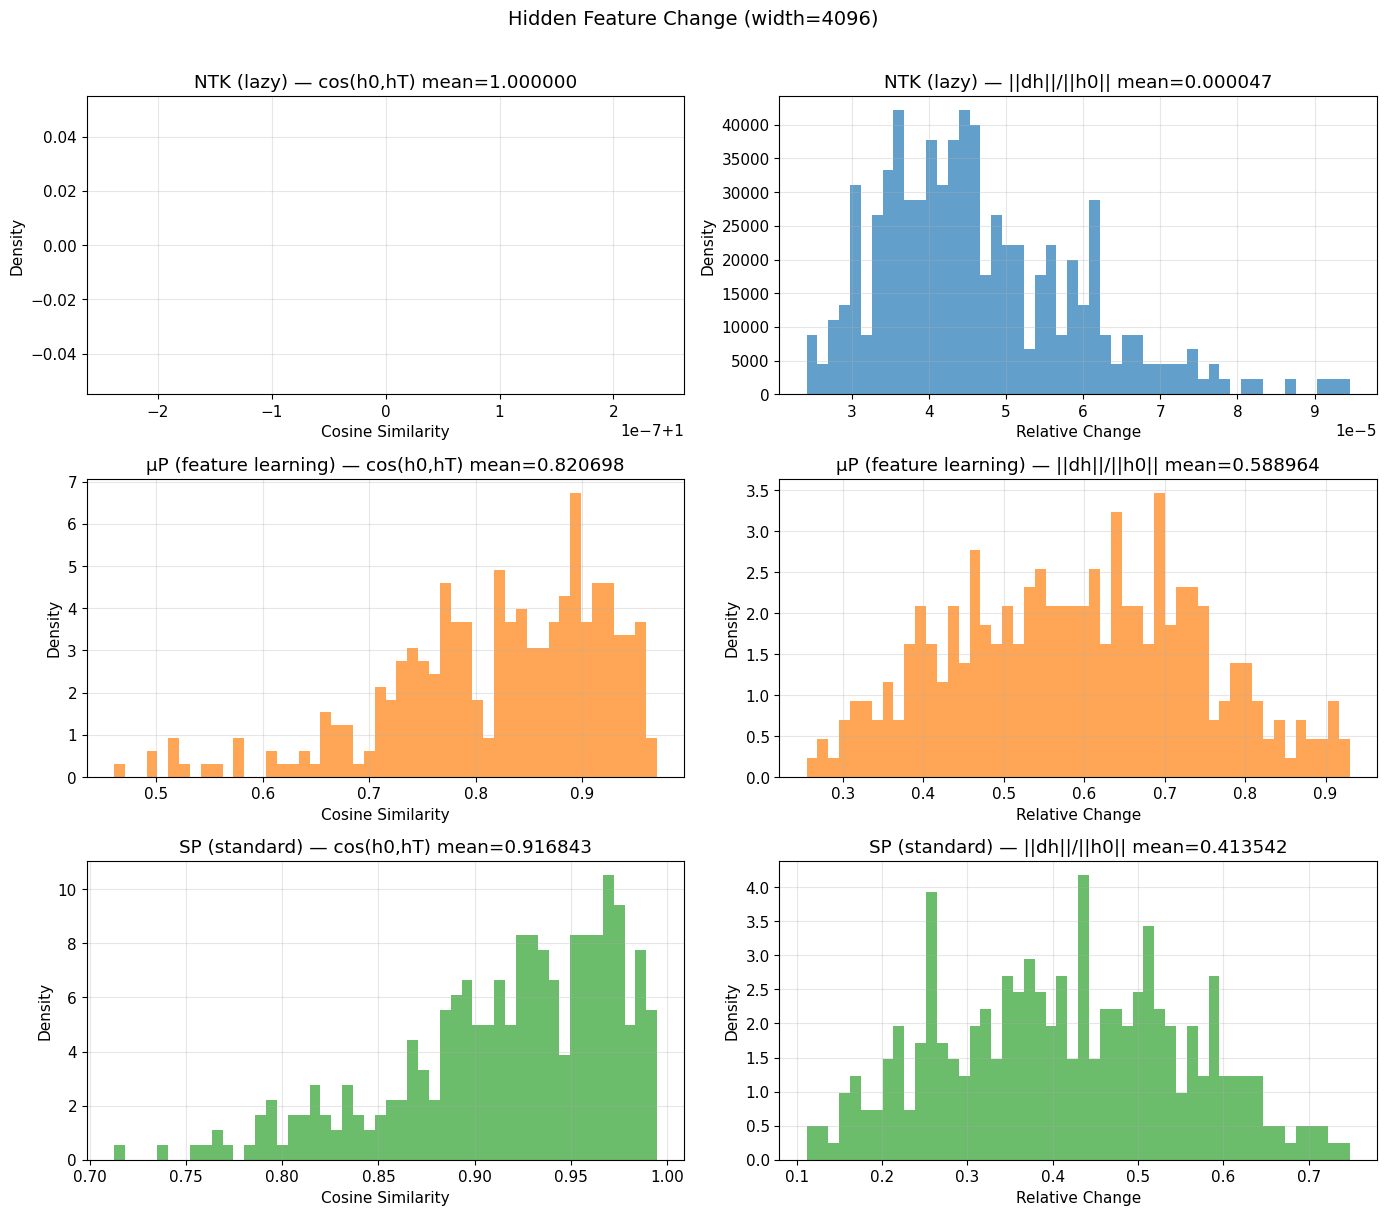


NTK: cos=1.000000, rel=0.000047  -> lazy
muP: cos=0.8207,  rel=0.5890   -> feature learning
SP:  cos=0.9168,  rel=0.4135


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
data = [
    ('NTK (lazy)',           cos_ntk, rel_ntk, 'C0'),
    ('μP (feature learning)', cos_mup, rel_mup, 'C1'),
    ('SP (standard)',        cos_sp,  rel_sp,  'C2'),
]

for row, (label, cos, rel, color) in enumerate(data):
    axes[row, 0].hist(cos, bins=50, alpha=0.7, color=color, density=True)
    axes[row, 0].set_title(f'{label} — cos(h0,hT) mean={cos.mean():.6f}')
    axes[row, 0].set_xlabel('Cosine Similarity')
    axes[row, 0].set_ylabel('Density')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].hist(rel, bins=50, alpha=0.7, color=color, density=True)
    axes[row, 1].set_title(f'{label} — ||dh||/||h0|| mean={rel.mean():.6f}')
    axes[row, 1].set_xlabel('Relative Change')
    axes[row, 1].set_ylabel('Density')
    axes[row, 1].grid(True, alpha=0.3)

fig.suptitle(f'Hidden Feature Change (width={wt})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nNTK: cos={cos_ntk.mean():.6f}, rel={rel_ntk.mean():.6f}  -> lazy')
print(f'muP: cos={cos_mup.mean():.4f},  rel={rel_mup.mean():.4f}   -> feature learning')
print(f'SP:  cos={cos_sp.mean():.4f},  rel={rel_sp.mean():.4f}')

---
## 实验 C: 权重分布 & 奇异值谱演化

- **SP**: 分布可能有些变化
- **μP**: 分布展宽, top SV 出现 spike → 学到低秩数据结构
- μP 的 outlier SV 正是 DAWN 中 head subspace 的物理来源

In [13]:
def track_weight_and_svd(mode, width=4096, lr=0.1, ep=10, seed=1):
    print(f'\n{"=" * 95}')
    print(f'  {mode.upper()} (width={width}, lr={lr}, epochs={ep})')
    print(f'{"=" * 95}')

    torch.manual_seed(seed)
    if mode == 'mup':
        net = muMLP(width=width, nonlin=nonlin,
                    output_mult=output_mult, input_mult=input_mult).to(device)
        set_base_shapes(net, base_shapes_path)
        opt = MuSGD(net.parameters(), lr=lr)
    else:
        net = MLP(width=width, nonlin=nonlin,
                  output_mult=output_mult, input_mult=input_mult).to(device)
        opt = SGD(net.parameters(), lr=lr)

    w0 = net.fc_2.weight.data.clone()
    w0n = w0.norm().item()
    dist_snap, sv_snap = {}, {}

    print(f'{"ep":>3s} {"tr_l":>7s} {"te_l":>7s} {"tr_a":>6s} {"te_a":>6s} {"gap":>6s} '
          f'{"W2_std":>9s} {"dW/W0":>10s} '
          f'{"s1":>7s} {"s5":>7s} {"s_min":>7s} {"eff_rank":>9s}')
    print('-' * 95)

    for e in range(0, ep + 1):
        if e > 0:
            train(net, device, train_loader, opt, e, criterion=criterion)

        tr_l, tr_a = evaluate(net, device, train_loader, criterion)
        te_l, te_a = evaluate(net, device, test_loader, criterion)

        W = net.fc_2.weight.data.cpu()
        wf = W.numpy().flatten()
        S = torch.linalg.svdvals(W).numpy()
        dr = (net.fc_2.weight.data - w0.to(device)).norm().item() / (w0n + 1e-10)
        er = np.sum(S)**2 / (np.sum(S**2) + 1e-10)

        print(f'{e:>3d} {tr_l:>7.4f} {te_l:>7.4f} '
              f'{tr_a:>6.3f} {te_a:>6.3f} {tr_a - te_a:>+6.3f} '
              f'{wf.std():>9.6f} {dr:>10.6f} '
              f'{S[0]:>7.4f} {S[4]:>7.4f} {S[-1]:>7.4f} '
              f'{er:>8.1f}/{len(S)}')

        if e in [0, 1, 2, 3, 5, 7, 10]:
            dist_snap[e] = wf.copy()
            sv_snap[e] = S.copy()

    return dist_snap, sv_snap

In [14]:
wd = 4096
d_sp,  s_sp  = track_weight_and_svd('sp',  wd, lr=0.1, ep=10)
d_mup, s_mup = track_weight_and_svd('mup', wd, lr=0.1, ep=10)


  SP (width=4096, lr=0.1, epochs=10)
 ep    tr_l    te_l   tr_a   te_a    gap    W2_std      dW/W0      s1      s5   s_min  eff_rank
-----------------------------------------------------------------------------------------------
  0  2.3026  2.3026  0.100  0.100 +0.000  0.015623   0.000000  1.9973  1.9826  0.0000   2950.9/4096
  1  2.2908  2.2897  0.115  0.115 -0.000  0.122975   8.000728 487.1080 24.9627  0.0002     72.8/4096
  2  2.6673  2.6584  0.134  0.135 -0.001  0.122968   8.001628 487.1361 25.0926  0.0002     73.0/4096
  3  2.2946  2.2951  0.113  0.114 -0.001  0.122961   8.002105 487.1521 25.1329  0.0001     73.0/4096
  4  2.2934  2.2947  0.110  0.110 +0.000  0.122962   8.003994 487.2175 25.6272  0.0000     73.1/4096
  5  2.2868  2.2851  0.121  0.121 -0.001  0.122961   8.004474 487.2293 25.7630  0.0003     73.2/4096
  6  2.2826  2.2855  0.122  0.120 +0.003  0.122969   8.006234 487.2823 26.3809  0.0003     73.3/4096
  7  2.3004  2.2966  0.128  0.128 -0.000  0.122966   8.006939 48

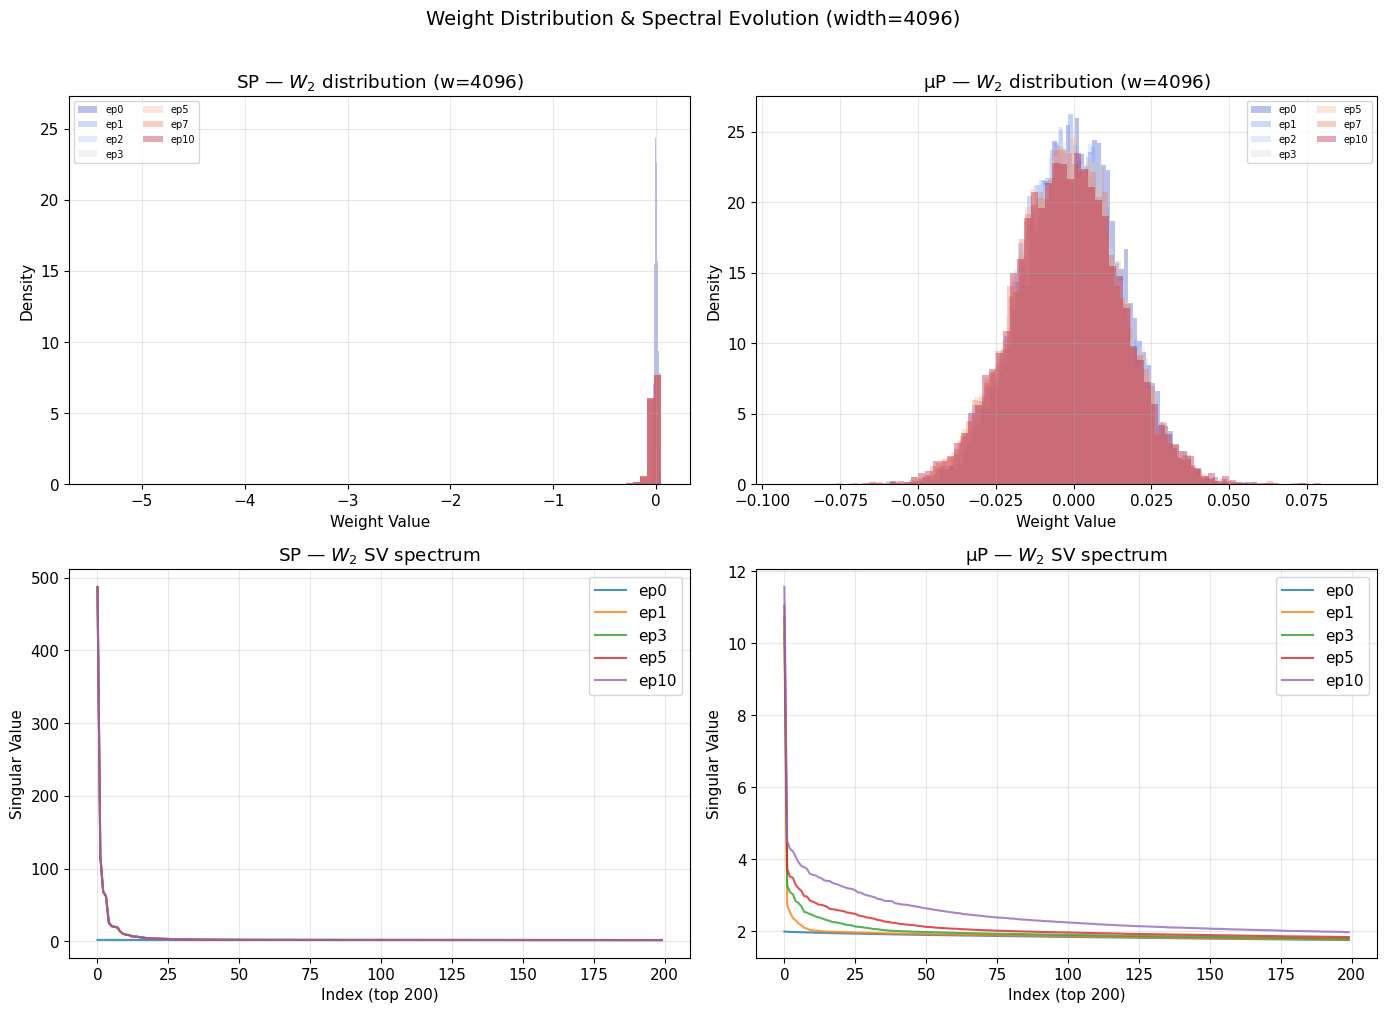

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cmap = plt.cm.coolwarm

# Row 0: Weight distributions
for ax, d, t in [(axes[0, 0], d_sp, 'SP'), (axes[0, 1], d_mup, 'μP')]:
    eps_list = sorted(d.keys())
    for i, ep in enumerate(eps_list):
        sub = d[ep][::max(1, len(d[ep]) // 10000)]
        ax.hist(sub, 80, alpha=0.35, density=True,
                color=cmap(i / max(1, len(eps_list) - 1)),
                label=f'ep{ep}')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')
    ax.set_title(f'{t} — $W_2$ distribution (w={wd})')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

# Row 1: Singular value spectra
for ax, s, t in [(axes[1, 0], s_sp, 'SP'), (axes[1, 1], s_mup, 'μP')]:
    for ep in [0, 1, 3, 5, 10]:
        if ep in s:
            ax.plot(s[ep][:200], label=f'ep{ep}', alpha=0.8)
    ax.set_xlabel('Index (top 200)')
    ax.set_ylabel('Singular Value')
    ax.set_title(f'{t} — $W_2$ SV spectrum')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Weight Distribution & Spectral Evolution (width={wd})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

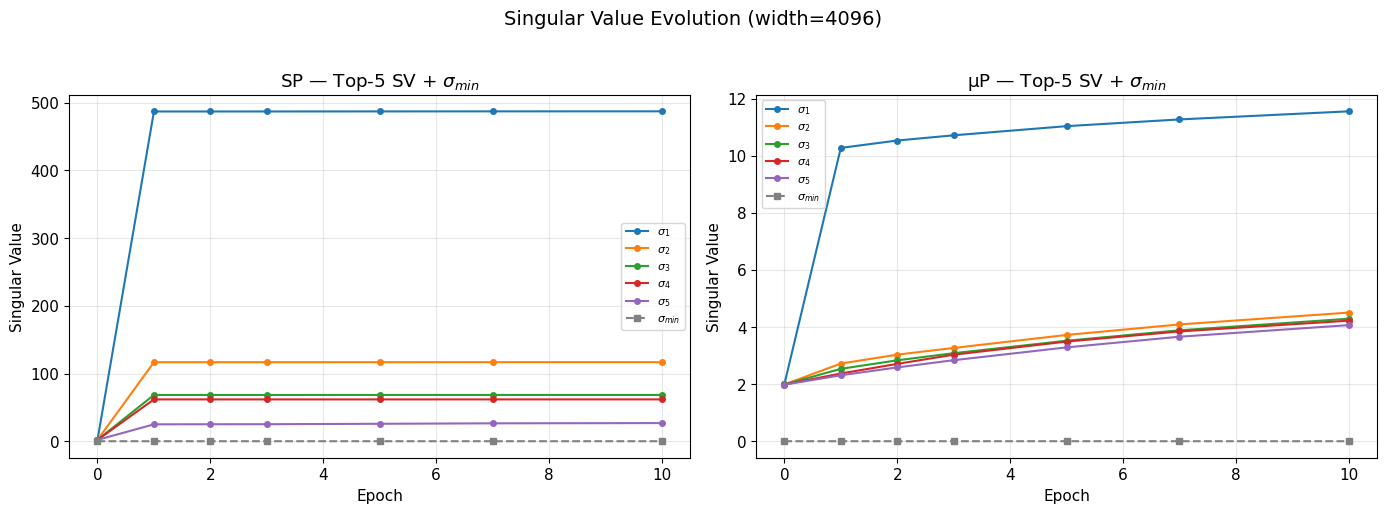


muP: top SV grow -> learned low-rank structure
This is the origin of DAWN head/tail decomposition:
  head (high-SNR) = outlier SVs -> full whitening
  tail (low-SNR)  = bulk MP     -> RMS normalization


In [16]:
# Top-5 SV evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, sv, t in [(ax1, s_sp, 'SP'), (ax2, s_mup, 'μP')]:
    eps_list = sorted(sv.keys())
    for k in range(5):
        ax.plot(eps_list, [sv[e][k] for e in eps_list],
                'o-', label=f'$\\sigma_{{{k+1}}}$', ms=4)
    ax.plot(eps_list, [sv[e][-1] for e in eps_list],
            's--', label='$\\sigma_{min}$', ms=4, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Singular Value')
    ax.set_title(f'{t} — Top-5 SV + $\\sigma_{{min}}$')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Singular Value Evolution (width={wd})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nmuP: top SV grow -> learned low-rank structure')
print('This is the origin of DAWN head/tail decomposition:')
print('  head (high-SNR) = outlier SVs -> full whitening')
print('  tail (low-SNR)  = bulk MP     -> RMS normalization')

---
## 实验 D: 完整训练曲线 (Train vs Test)

In [ ]:
def full_train_curve(mode, width=2048, lr=0.1, ep=20, seed=1):
    print(f'\n=== {mode.upper()} w={width} lr={lr} ===')
    torch.manual_seed(seed)

    if mode == 'mup':
        net = muMLP(width=width, nonlin=nonlin,
                    output_mult=output_mult, input_mult=input_mult).to(device)
        set_base_shapes(net, base_shapes_path)
        opt = MuSGD(net.parameters(), lr=lr)
    else:
        net = MLP(width=width, nonlin=nonlin,
                  output_mult=output_mult, input_mult=input_mult).to(device)
        opt = SGD(net.parameters(), lr=lr)

    w0 = {n: p.data.clone() for n, p in net.named_parameters()}

    tr0_l, tr0_a = evaluate(net, device, train_loader, criterion)
    te0_l, te0_a = evaluate(net, device, test_loader, criterion)

    print(f'{"ep":>3s} {"tr_l":>7s} {"te_l":>7s} '
          f'{"tr_a":>6s} {"te_a":>6s} {"gap":>6s} '
          f'{"dW2/W20":>10s}')
    print(f'{0:>3d} {tr0_l:>7.4f} {te0_l:>7.4f} '
          f'{tr0_a:>6.3f} {te0_a:>6.3f} {tr0_a - te0_a:>+6.3f} '
          f'{0.0:>10.6f}')

    h = {'ep': [0], 'tr_l': [tr0_l], 'te_l': [te0_l],
         'tr_a': [tr0_a], 'te_a': [te0_a]}

    for e in range(1, ep + 1):
        train(net, device, train_loader, opt, e, criterion=criterion)
        tr_l, tr_a = evaluate(net, device, train_loader, criterion)
        te_l, te_a = evaluate(net, device, test_loader, criterion)
        dw = (net.fc_2.weight.data - w0['fc_2.weight'].to(device)).norm().item()
        wn = w0['fc_2.weight'].norm().item()
        print(f'{e:>3d} {tr_l:>7.4f} {te_l:>7.4f} '
              f'{tr_a:>6.3f} {te_a:>6.3f} {tr_a - te_a:>+6.3f} '
              f'{dw / (wn + 1e-10):>10.6f}')
        h['ep'].append(e)
        h['tr_l'].append(tr_l)
        h['te_l'].append(te_l)
        h['tr_a'].append(tr_a)
        h['te_a'].append(te_a)

    return h


W = 2048
h_mup = full_train_curve('mup', W, lr=0.1, ep=20)
h_sp  = full_train_curve('sp',  W, lr=0.1, ep=20)


=== MUP w=2048 lr=0.1 ===
 ep    tr_l    te_l   tr_a   te_a    gap    dW2/W20
  0  2.3026  2.3026  0.100  0.100 +0.000   0.000000
  1  2.5824  2.6239  0.319  0.314 +0.005   0.347944
  2  1.5668  1.7277  0.450  0.408 +0.042   0.386203
  3  1.3527  1.6878  0.517  0.426 +0.091   0.426512
  4  1.1945  1.7368  0.582  0.443 +0.139   0.470170
  5  0.9701  1.6667  0.663  0.467 +0.196   0.516935
  6  0.7588  1.7915  0.739  0.479 +0.259   0.564230
  7  0.6950  2.0133  0.774  0.485 +0.289   0.611529
  8  1.4897  3.1405  0.732  0.443 +0.289   0.656121
  9  0.7490  2.6239  0.799  0.449 +0.351   0.698233
 10  1.5393  3.7591  0.767  0.442 +0.326   0.734668
 11  0.4119  2.5949  0.880  0.479 +0.401   0.767304
 12  0.2214  2.5852  0.927  0.504 +0.423   0.796752
 13  1.4033  4.1279  0.805  0.444 +0.361   0.823734
 14  0.1487  2.7709  0.951  0.495 +0.456   0.850867
 15  0.1149  2.8778  0.963  0.511 +0.453   0.871277
 16  0.1955  3.0801  0.940  0.494 +0.446   0.893446
 17  0.1345  3.1004  0.957  0.497 +0.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for h, lb in [(h_mup, 'μP'), (h_sp, 'SP')]:
    axes[0].plot(h['ep'], h['tr_l'], '-',  label=f'{lb} train')
    axes[0].plot(h['ep'], h['te_l'], '--', label=f'{lb} test')
    axes[1].plot(h['ep'], h['tr_a'], '-',  label=f'{lb} train')
    axes[1].plot(h['ep'], h['te_a'], '--', label=f'{lb} test')
    gap = [a - b for a, b in zip(h['tr_a'], h['te_a'])]
    axes[2].plot(h['ep'], gap, '-o', label=lb, ms=3)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train Acc - Test Acc')
axes[2].set_title('Generalization Gap'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color='gray', ls=':', lw=0.8)

fig.suptitle(f'Training Curves (width={W})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()